#RETRIEVAL AUGMENTED GENERATION

##0.REFERENCES AND CONTEXT

**Introduction**

Retrieval-Augmented Generation (RAG) is one of the most important developments in modern artificial intelligence. While large language models possess remarkable reasoning and language generation capabilities, they suffer from a fundamental limitation: their knowledge is frozen at training time. They cannot automatically access proprietary documents, recent events, internal databases, research papers, or organization-specific knowledge. Retrieval-Augmented Generation addresses this limitation by combining information retrieval techniques with generative AI.

The central idea behind RAG is deceptively simple. Instead of asking a language model to answer a question solely from its internal parameters, the system first retrieves relevant information from an external knowledge base. This retrieved information is then supplied to the language model as context, enabling grounded and evidence-based responses. In effect, the model gains access to a dynamic memory system that can be updated without retraining.

Modern enterprise AI systems are overwhelmingly built around RAG architectures. Financial research assistants retrieve market reports before generating analysis. Legal assistants retrieve contracts and regulations before answering questions. Medical assistants retrieve clinical guidelines before making recommendations. Internal corporate assistants retrieve policies, procedures, and documentation before responding to employees. In all these cases, retrieval dramatically reduces hallucinations and improves accuracy.

This notebook introduces the complete RAG workflow. Students will construct a synthetic financial knowledge base, split documents into chunks, generate embeddings, build a vector database using FAISS, perform semantic retrieval, and generate grounded answers using GPT-5.2. Each stage of the pipeline is implemented explicitly so students can understand the underlying mechanics rather than treating RAG as a black box.

The notebook also introduces vector embeddings, one of the most powerful concepts in modern machine learning. Embeddings transform text into numerical vectors that capture semantic meaning. Similar documents occupy nearby positions in embedding space, enabling efficient similarity search. This capability forms the foundation of modern retrieval systems.

By the end of this chapter, students will understand how enterprise AI systems combine retrieval and generation, how vector databases work, how semantic search differs from keyword search, and why Retrieval-Augmented Generation has become the dominant architecture for practical AI deployment.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the environment, installs required libraries, configures reproducibility, and creates project folders.

In [1]:
# CELL 1
# Environment Setup

!pip -q install sentence-transformers faiss-cpu openai

import json
import random
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import faiss

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

PROJECT_DIR = Path("/content/chapter14_rag")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RUN_ID = datetime.datetime.now(
    datetime.timezone.utc
).strftime("run_%Y%m%d_%H%M%S_utc")

print("Run ID:", RUN_ID)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 126.0 MB/s eta 0:00:00
Run ID: run_20260606_140425_utc


##2.THE SYNTHETIC FINANCIAL KNOWLEDGE

**Explanation for Cell 2**

This cell creates a synthetic financial knowledge base that will serve as the document repository for the retrieval system.

In [2]:
# CELL 2
# Synthetic Knowledge Base

knowledge_base = []

topics = [
    "Portfolio Diversification",
    "Modern Portfolio Theory",
    "Risk Management",
    "Factor Investing",
    "Inflation",
    "Interest Rates",
    "Machine Learning",
    "Artificial Intelligence",
    "Asset Allocation",
    "Behavioral Finance"
]

for topic in topics:

    for i in range(15):

        knowledge_base.append(
            {
                "id": len(knowledge_base),
                "topic": topic,
                "text": (
                    f"{topic} document {i}. "
                    f"This document explains concepts related to {topic}. "
                    f"It contains educational content about finance, economics, "
                    f"investment management, and decision making."
                )
            }
        )

print(
    "Documents:",
    len(knowledge_base)
)

print(
    knowledge_base[0]
)

Documents: 150
{'id': 0, 'topic': 'Portfolio Diversification', 'text': 'Portfolio Diversification document 0. This document explains concepts related to Portfolio Diversification. It contains educational content about finance, economics, investment management, and decision making.'}


##3.CONVERTING DOCUMENTS INTO CHUNKS

**Explanation for Cell 3**

This cell converts documents into chunks suitable for embedding generation.

In [3]:
# CELL 3
# Chunk Documents

chunks = []

for document in knowledge_base:

    chunks.append(
        {
            "document_id":
                document["id"],

            "topic":
                document["topic"],

            "text":
                document["text"]
        }
    )

print(
    "Chunks:",
    len(chunks)
)

Chunks: 150


##4.THE SENTENCE EMBEDDINGS

**Explanation for Cell 4**

This cell generates vector embeddings using a sentence-transformer model.

In [4]:
# CELL 4
# Generate Embeddings

from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

texts = [
    chunk["text"]
    for chunk in chunks
]

embeddings = embedding_model.encode(
    texts,
    show_progress_bar=True
)

embeddings = np.array(
    embeddings,
    dtype=np.float32
)

print(
    embeddings.shape
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

(150, 384)


##5.THE FAISS VECTOR DATABASE

**Explanation for Cell 5**

This cell builds a FAISS vector database.

In [5]:
# CELL 5
# Build FAISS Index

embedding_dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(
    embedding_dimension
)

index.add(
    embeddings
)

print(
    "Vectors Indexed:",
    index.ntotal
)

Vectors Indexed: 150


##6.CONVERSIONS OF QUESTIONS INTO EMBEDDING REPRESENTATION

**Explanation for Cell 6**

This cell converts a user question into an embedding representation.

In [6]:
# CELL 6
# Query Embedding

query = (
    "How does diversification reduce portfolio risk?"
)

query_embedding = embedding_model.encode(
    [query]
)

query_embedding = np.array(
    query_embedding,
    dtype=np.float32
)

print(
    query_embedding.shape
)

(1, 384)


##7.SEMANTIC SIMILARITY SEARCH

**Explanation for Cell 7**

This cell performs semantic similarity search against the vector database.

In [7]:
# CELL 7
# Similarity Search

TOP_K = 5

distances, indices = index.search(
    query_embedding,
    TOP_K
)

print(indices)
print(distances)

[[10  9  7  4 11]]
[[0.64814806 0.65684754 0.663877   0.67417455 0.67751014]]


##8.RETRIEVAL OF THE MOST RELEVANT DOCUMENTS

**Explanation for Cell 8**

This cell retrieves the most relevant documents.

In [8]:
# CELL 8
# Retrieve Documents

retrieved_documents = []

for idx in indices[0]:

    retrieved_documents.append(
        chunks[idx]
    )

for document in retrieved_documents:

    print("\n")
    print(
        document["topic"]
    )

    print(
        document["text"]
    )



Portfolio Diversification
Portfolio Diversification document 10. This document explains concepts related to Portfolio Diversification. It contains educational content about finance, economics, investment management, and decision making.


Portfolio Diversification
Portfolio Diversification document 9. This document explains concepts related to Portfolio Diversification. It contains educational content about finance, economics, investment management, and decision making.


Portfolio Diversification
Portfolio Diversification document 7. This document explains concepts related to Portfolio Diversification. It contains educational content about finance, economics, investment management, and decision making.


Portfolio Diversification
Portfolio Diversification document 4. This document explains concepts related to Portfolio Diversification. It contains educational content about finance, economics, investment management, and decision making.


Portfolio Diversification
Portfolio Diversifi

##9.THE GRAUNDED ANSWER

**Explanation for Cell 9**

This cell generates a grounded answer using GPT-5.2 and the retrieved evidence.

In [9]:
# CELL 9
# Grounded Generation

from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get(
        "OPENAI_API_KEY"
    )
)

context = "\n\n".join(
    [
        doc["text"]
        for doc in retrieved_documents
    ]
)

prompt = f"""
Question:

{query}

Retrieved Context:

{context}

Answer the question only using
the retrieved context.
"""

response = client.responses.create(
    model="gpt-5.2",
    input=prompt
)

rag_answer = response.output_text

print(rag_answer)

Diversification reduces portfolio risk by spreading investments across different assets so the portfolio is not overly exposed to the performance of any single investment. Because different assets and sectors respond differently to economic and market conditions, losses in one holding can be offset by gains or smaller losses in others, which lowers the overall volatility of portfolio returns. This helps reduce *unsystematic (asset-specific)* risk, though it does not eliminate *systematic (market-wide)* risk.


##10.EVALUATION OF RETRIEVAL QUALITY

**Explanation for Cell 10**

This cell evaluates retrieval quality and visualizes retrieval scores.

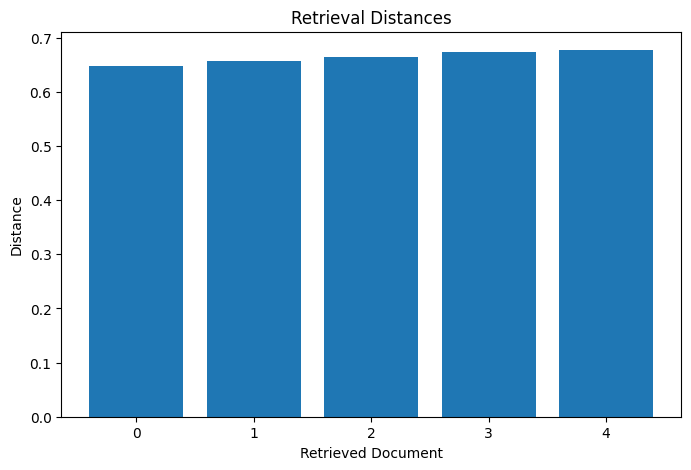

   Rank  Distance
0     1  0.648148
1     2  0.656848
2     3  0.663877
3     4  0.674175
4     5  0.677510


In [10]:
# CELL 10
# Retrieval Evaluation

scores = distances[0]

plt.figure(
    figsize=(8,5)
)

plt.bar(
    range(len(scores)),
    scores
)

plt.title(
    "Retrieval Distances"
)

plt.xlabel(
    "Retrieved Document"
)

plt.ylabel(
    "Distance"
)

plt.show()

retrieval_results = pd.DataFrame(
    {
        "Rank":
            range(1, TOP_K + 1),

        "Distance":
            scores
    }
)

print(
    retrieval_results
)

##11.EXPLANATION AND SUMMARIZATION

In [11]:
# CELL 11
# GPT-5.2 Notebook Explanation

summary = {
    "documents":
        len(knowledge_base),

    "chunks":
        len(chunks),

    "embedding_dimension":
        int(embedding_dimension),

    "top_k":
        TOP_K,

    "query":
        query
}

response = client.responses.create(
    model="gpt-5.2",
    input=f"""
Explain this RAG experiment.

Return strict JSON.

{json.dumps(summary, indent=2)}
"""
)

print(
    response.output_text
)

{
  "overview": "This experiment evaluates a Retrieval-Augmented Generation (RAG) setup where a user query is answered by first retrieving the most relevant text chunks from a corpus and then using those chunks as context for generation.",
  "given_configuration": {
    "documents": 150,
    "chunks": 150,
    "embedding_dimension": 384,
    "top_k": 5,
    "query": "How does diversification reduce portfolio risk?"
  },
  "what_each_field_means": {
    "documents": "The corpus contains 150 source documents.",
    "chunks": "The indexing unit is 150 chunks total. Since chunks == documents, this likely means each document was stored as exactly one chunk (little/no splitting), or documents were pre-chunked into one segment each.",
    "embedding_dimension": "Each document/chunk and the query are represented as 384-dimensional vectors produced by the embedding model. Similarity search happens in this vector space.",
    "top_k": "At query time, the system retrieves the 5 most similar chunk

##12.CONCLUSIONS

**Conclusion**

This notebook introduced Retrieval-Augmented Generation, one of the most important architectures in modern artificial intelligence. Unlike standalone language models that rely exclusively on their internal parameters, RAG systems dynamically retrieve information from external knowledge sources before generating responses. This capability dramatically improves accuracy, reduces hallucinations, and enables AI systems to operate on continuously updated information.

Students learned how a complete retrieval pipeline operates. Documents were transformed into chunks, chunks were converted into vector embeddings, embeddings were stored in a FAISS vector database, semantic similarity search identified relevant information, and GPT-5.2 generated answers grounded in retrieved evidence. Together, these components form the foundation of many production AI systems.

The notebook also demonstrated the importance of embeddings. By converting text into numerical vectors, semantic meaning becomes measurable. Similar concepts occupy nearby regions in embedding space, enabling retrieval systems to identify relevant information even when exact keywords differ. This semantic capability represents a major improvement over traditional keyword search systems.

The FAISS vector database illustrated how modern AI systems store and retrieve large collections of documents efficiently. Vector search has become a critical component of enterprise AI because organizations increasingly rely on proprietary information that is unavailable to foundation models during training.

Perhaps the most important lesson from this chapter is that modern AI applications rarely rely on language models alone. Instead, they combine retrieval, generation, reasoning, and external knowledge sources into integrated systems. Retrieval-Augmented Generation provides the first major step toward these more sophisticated architectures.

This chapter also serves as the foundation for the remaining notebooks in the Machine Learning Laboratory series. Agentic retrieval systems, fine-tuning workflows, multi-agent architectures, and reasoning systems all depend heavily on retrieval mechanisms. Understanding RAG is therefore essential for understanding how modern production AI systems operate.

In the next chapter, students will extend this architecture by introducing Agentic Retrieval Systems. Rather than performing a single retrieval step, autonomous agents will learn to plan, search, retrieve, evaluate evidence, and iteratively refine their knowledge acquisition process. This transition marks the beginning of the agentic AI portion of the curriculum and provides a bridge toward advanced autonomous reasoning systems.